<a href="https://colab.research.google.com/github/seamusmack/AIML-Resources/blob/main/Copy_of_Uber_Case_Study_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Artificial Intelligence and Machine Learning</center></font></h1>
<h1><center>Exploratory Data Analysis - Week 3</center></h1>

<center><img src="https://upload.wikimedia.org/wikipedia/commons/d/d6/UBER_%281%29.jpg" width="800" height="400"></center>

<b><h2><center>Uber Case Study</center></h2></b>

### **Context:**
Ridesharing is a service that arranges transportation on short notice. It is a very volatile market and its demand fluctuates wildly with time, place, weather, local events, etc. The key to being successful in this business is to be able to detect patterns in these fluctuations and cater to the demand at any given time.  

### **Objective:**
Uber Technologies, Inc. is an American multinational transportation network company based in San Francisco and has operations in over 785 metropolitan areas with over 110 million users worldwide. As a newly hired Data Scientist in Uber's New York Office, you have been given the task of extracting actionable insights from data that will help in the growth of the the business.

### **Key Questions:**
1. What are the different variables that influence the number of pickups?
2. Which factor affects the number of pickups the most? What could be the possible reasons for that?
3. What are your recommendations to Uber management to capitalize on fluctuating demand?

### **Data Description:**
The data contains the details for the Uber rides across various boroughs (subdivisions) of New York City at an hourly level and attributes associated with weather conditions at that time.

* pickup_dt: Date and time of the pick-up
* borough: NYC's borough
* pickups: Number of pickups for the period (hourly)
* spd: Wind speed in miles/hour
* vsb: Visibility in miles to the nearest tenth
* temp: Temperature in Fahrenheit
* dewp: Dew point in Fahrenheit
* slp: Sea level pressure
* pcp01: 1-hour liquid precipitation
* pcp06: 6-hour liquid precipitation
* pcp24: 24-hour liquid precipitation
* sd: Snow depth in inches
* hday: Being a holiday (Y) or not (N)

In [ ]:
# Cell 1

# === Preflight: lightweight, Colab-safe setup ===
import sys, platform, subprocess, importlib

print(f"Python:  {sys.version.split()[0]}  |  Platform: {platform.platform()}")
print("Checking required libraries...")

def ensure(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
        print(f"✓ {pkg} already available")
    except Exception:
        print(f"→ Installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# Core EDA stack (avoid downgrading numpy/pandas in Colab)
for p in [
    "pandas",          # dataframes
    "numpy",           # numerics
    "matplotlib",      # plotting
    "seaborn",         # stat plots (optional but useful for EDA speed)
    "scikit-learn",    # metrics, preprocessing
    "missingno",       # NaN visualizations
    "plotly",          # interactive exploration
    "kaleido",         # static export for plotly if needed
]:
    ensure(p)

# Nice-to-haves; skip if you don't use them
# ensure("polars")
# ensure("pyarrow")

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import missingno as msno
from sklearn import __version__ as skver

print("\n== Library versions ==")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
import matplotlib; print("matplotlib:", matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scikit-learn:", skver)

# Pandas/plot display prefs
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Matplotlib defaults for readability
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.autolayout": True,
})

print("\nPreflight complete. No runtime restart required.")


Python:  3.11.13  |  Platform: Linux-6.1.123+-x86_64-with-glibc2.35
Checking required libraries...
✓ pandas already available
✓ numpy already available
✓ matplotlib already available
✓ seaborn already available
→ Installing scikit-learn ...
✓ missingno already available
✓ plotly already available
→ Installing kaleido ...

== Library versions ==
pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
scikit-learn: 1.6.1

Preflight complete. No runtime restart required.


In [4]:
# Cell 2

# === Data loading from Google Drive (final streamlined version) ===
from google.colab import drive
import pandas as pd
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Path to your dataset
DATA_PATH = Path("/content/drive/MyDrive/Colab Notebooks/dataset(s)/Uber_Data.csv")

# Check file
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

# Load dataset
data = pd.read_csv(DATA_PATH)

# Schema check
REQUIRED_COLUMNS = ["pickup_dt", "borough", "pickups"]  # match actual column casing
missing_cols = [c for c in REQUIRED_COLUMNS if c not in data.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

# Parse datetime
data["pickup_dt"] = pd.to_datetime(data["pickup_dt"], errors="coerce")
if data["pickup_dt"].isna().any():
    print("⚠ Some pickup_dt values could not be parsed.")

# Defensive copy
df = data.copy()

# Summary
print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head())
display(df.info())
display(df.describe(include="all"))


Mounted at /content/drive
⚠ Some pickup_dt values could not be parsed.
✅ Dataset loaded: 29,101 rows × 13 columns


,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,NaN,7.0,1023.5,0.0,0.0,0.0,0.0,Y
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
3,2015-01-01 01:00:00,Manhattan,5258,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
4,2015-01-01 01:00:00,Queens,405,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29101 entries, 0 to 29100
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   pickup_dt  11542 non-null  datetime64[ns]
 1   borough    26058 non-null  object        
 2   pickups    29101 non-null  int64         
 3   spd        29101 non-null  float64       
 4   vsb        29101 non-null  float64       
 5   temp       28742 non-null  float64       
 6   dewp       29101 non-null  float64       
 7   slp        29101 non-null  float64       
 8   pcp01      29101 non-null  float64       
 9   pcp06      29101 non-null  float64       
 10  pcp24      29101 non-null  float64       
 11  sd         29101 non-null  float64       
 12  hday       29101 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 2.9+ MB


None

,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
count,11542,26058,29101.000000,29101.000000,29101.000000,28742.000000,29101.000000,29101.000000,29101.000000,29101.000000,29101.000000,29101.000000,29101
unique,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Bronx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N
freq,NaN,4343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27980
mean,2015-06-19 21:03:22.114018304,NaN,490.215903,5.984924,8.818125,47.900019,30.823065,1017.817938,0.003830,0.026129,0.090464,2.529169,NaN
min,2015-01-01 01:00:00,NaN,0.000000,0.000000,0.000000,2.000000,-16.000000,991.400000,0.000000,0.000000,0.000000,0.000000,NaN
25%,2015-04-01 01:15:00,NaN,1.000000,3.000000,9.100000,32.000000,14.000000,1012.500000,0.000000,0.000000,0.000000,0.000000,NaN
50%,2015-07-01 02:00:00,NaN,54.000000,6.000000,10.000000,46.500000,30.000000,1018.200000,0.000000,0.000000,0.000000,0.000000,NaN
75%,2015-10-01 00:45:00,NaN,449.000000,8.000000,10.000000,65.000000,50.000000,1022.900000,0.000000,0.000000,0.050000,2.958333,NaN
max,2015-12-06 23:00:00,NaN,7883.000000,21.000000,10.000000,89.000000,73.000000,1043.400000,0.280000,1.240000,2.100000,19.000000,NaN


In [5]:
# Cell 3

# Basic structure and sanity review
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print("Columns:", list(df.columns))

display(df.sample(5).sort_index())     # random rows for quick visual check
display(df.head(3))                    # first rows in temporal order
display(df.tail(3))                    # last rows

print("\n.info():")
display(df.info())

print("\n.describe(numeric):")
display(df.describe())

# Quickly check uniqueness and min/max for key fields
print("\nUnique borough values and counts:")
display(df['borough'].value_counts(dropna=False).to_frame('count'))

print("\nDatetime range:")
print(df['pickup_dt'].min(), "→", df['pickup_dt'].max())


Rows: 29,101  |  Columns: 13
Columns: ['pickup_dt', 'borough', 'pickups', 'spd', 'vsb', 'temp', 'dewp', 'slp', 'pcp01', 'pcp06', 'pcp24', 'sd', 'hday']


,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
9660,2015-02-03 16:00:00,Manhattan,1995,15.0,9.55,34.0,17.5,1021.1,0.00,0.00,0.000000,12.291667,N
10756,2015-09-03 12:00:00,EWR,0,3.0,9.10,42.0,30.0,1020.8,0.01,0.01,0.010000,15.125000,N
12465,NaT,EWR,0,6.0,10.00,36.0,3.0,1027.5,0.00,0.01,0.000000,0.000000,N
13431,NaT,NaN,2,0.0,4.00,42.0,39.0,1019.2,0.00,0.01,0.368333,0.000000,N
18549,NaT,Manhattan,1012,6.0,10.00,51.0,29.0,1005.1,0.00,0.02,0.705000,0.000000,N


,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,NaN,7.0,1023.5,0.0,0.0,0.0,0.0,Y
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,0.0,0.0,Y


,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd,hday
29098,NaT,Queens,580,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29099,NaT,Staten Island,0,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N
29100,NaT,NaN,3,7.0,10.0,75.0,65.0,1011.8,0.0,0.0,0.0,0.0,N



.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29101 entries, 0 to 29100
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   pickup_dt  11542 non-null  datetime64[ns]
 1   borough    26058 non-null  object        
 2   pickups    29101 non-null  int64         
 3   spd        29101 non-null  float64       
 4   vsb        29101 non-null  float64       
 5   temp       28742 non-null  float64       
 6   dewp       29101 non-null  float64       
 7   slp        29101 non-null  float64       
 8   pcp01      29101 non-null  float64       
 9   pcp06      29101 non-null  float64       
 10  pcp24      29101 non-null  float64       
 11  sd         29101 non-null  float64       
 12  hday       29101 non-null  object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 2.9+ MB


...


.describe(numeric):


,pickup_dt,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,pcp24,sd
count,11542,29101.000000,29101.000000,29101.000000,28742.000000,29101.000000,29101.000000,29101.000000,29101.000000,29101.000000,29101.000000
mean,2015-06-19 21:03:22.114018304,490.215903,5.984924,8.818125,47.900019,30.823065,1017.817938,0.003830,0.026129,0.090464,2.529169
min,2015-01-01 01:00:00,0.000000,0.000000,0.000000,2.000000,-16.000000,991.400000,0.000000,0.000000,0.000000,0.000000
25%,2015-04-01 01:15:00,1.000000,3.000000,9.100000,32.000000,14.000000,1012.500000,0.000000,0.000000,0.000000,0.000000
50%,2015-07-01 02:00:00,54.000000,6.000000,10.000000,46.500000,30.000000,1018.200000,0.000000,0.000000,0.000000,0.000000
75%,2015-10-01 00:45:00,449.000000,8.000000,10.000000,65.000000,50.000000,1022.900000,0.000000,0.000000,0.050000,2.958333
max,2015-12-06 23:00:00,7883.000000,21.000000,10.000000,89.000000,73.000000,1043.400000,0.280000,1.240000,2.100000,19.000000
std,NaN,995.649536,3.699007,2.442897,19.798783,21.283444,7.768796,0.018933,0.093125,0.219402,4.520325



Unique borough values and counts:


,count
borough,
Bronx,4343
Brooklyn,4343
EWR,4343
Manhattan,4343
Queens,4343
Staten Island,4343
NaN,3043



Datetime range:
2015-01-01 01:00:00 → 2015-12-06 23:00:00


### **Missing value treatment**

One of the commonly used method to deal with the missing values is to impute them with the central tendencies - mean, median, and mode of a column.

* `Replacing with mean`: In this method the missing values are imputed with the mean of the column. Mean gets impacted by the presence of outliers, and in such cases where the column has outliers using this method may lead to erroneous imputations.

* `Replacing with median`: In this method the missing values are imputed with the median of the column. In cases where the column has outliers, median is an appropriate measure of central tendency to deal with the missing values over mean.

* `Replacing with mode`: In this method the missing values are imputed with the mode of the column. This method is generally preferred with categorical data.

Section: Missingness Audit
We quantify and visualize missing data to decide on imputation, omission, or “unknown as a category.” Weather fields often have sparse gaps; we will not impute yet—just observe.

,na_count,na_pct
pickup_dt,17559,60.34
borough,3043,10.46
temp,359,1.23
spd,0,0.00
pickups,0,0.00
vsb,0,0.00
dewp,0,0.00
slp,0,0.00
pcp01,0,0.00
pcp06,0,0.00


Missingno not available or plotting failed: name 'plt' is not defined


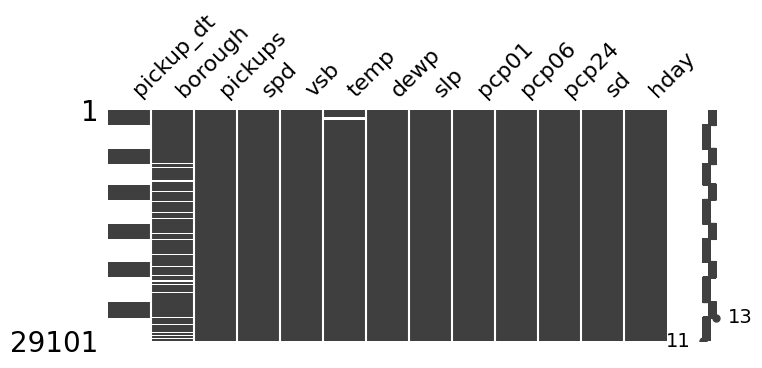

In [6]:
# Cell 4

import numpy as np

na_counts = df.isna().sum().sort_values(ascending=False)
na_ratio = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
missing_report = (
    pd.concat([na_counts, na_ratio], axis=1)
      .rename(columns={0: 'na_count', 1: 'na_pct'})
)
display(missing_report)

# Visualizations (safe if missingno installed in preflight)
try:
    import missingno as msno
    _ = msno.matrix(df, figsize=(8, 3))
    plt.title("Missingness Matrix")
    plt.show()

    _ = msno.heatmap(df, figsize=(6, 4))
    plt.title("Missingness Correlation Heatmap")
    plt.show()
except Exception as e:
    print(f"Missingno not available or plotting failed: {e}")


Section: Type Cleanup and Feature Engineering
Normalize names, set categorical types, derive time parts. Keep everything explicit to avoid SettingWithCopyWarning.

In [7]:
# Cell 5

# === Cell 5 — Column normalization, dtypes, and time features (NaT-safe) ===

# 1) Normalize column names
df.columns = df.columns.str.strip().str.lower()

# 2) Verify required columns
required = ["pickup_dt", "borough", "pickups"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns after normalization: {missing}")

# 3) Enforce core dtypes
df["pickup_dt"] = pd.to_datetime(df["pickup_dt"], errors="coerce")
df["borough"]   = df["borough"].astype("category")

# 4) Optional holiday handling
if "hday" in df.columns:
    df["hday"] = df["hday"].astype("category")
    df["is_holiday"] = df["hday"].map({"Y": True, "N": False})
else:
    df["is_holiday"] = False

# 5) Sort chronologically
df = df.sort_values("pickup_dt").reset_index(drop=True)

# 6) Cast numeric columns if present
numeric_candidates = ["pickups","vsb","temp","dewpt","slp","spd","pcp01","pcp06","pcp24","sd"]
for col in [c for c in numeric_candidates if c in df.columns]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 7) Derive time features with nullable int types
dt = df["pickup_dt"]
df["year"]      = dt.dt.year.astype("Int16")
df["month"]     = dt.dt.month.astype("Int8")
df["day"]       = dt.dt.day.astype("Int8")
df["hour"]      = dt.dt.hour.astype("Int8")
df["weekday"]   = dt.dt.dayofweek.astype("Int8")               # 0=Mon .. 6=Sun
df["week"]      = dt.dt.isocalendar().week.astype("Int16")
df["is_weekend"]= df["weekday"].isin([5, 6])

# 8) Preview
print("Post-feature columns:")
display(df.head(3))




Post-feature columns:


,pickup_dt,borough,pickups,spd,vsb,temp,dewp,slp,pcp01,pcp06,...,sd,hday,is_holiday,year,month,day,hour,weekday,week,is_weekend
0,2015-01-01 01:00:00,Bronx,152,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,...,0.0,Y,True,2015,1,1,1,3,1,False
1,2015-01-01 01:00:00,Brooklyn,1519,5.0,10.0,NaN,7.0,1023.5,0.0,0.0,...,0.0,Y,True,2015,1,1,1,3,1,False
2,2015-01-01 01:00:00,EWR,0,5.0,10.0,30.0,7.0,1023.5,0.0,0.0,...,0.0,Y,True,2015,1,1,1,3,1,False


Let's now perform the Exploratory Data Analysis on the dataset

### **Exploratory Data Analysis**

Section: Quick Sanity Plots
Objective: confirm temporal cadence and coarse seasonality before deep dives.

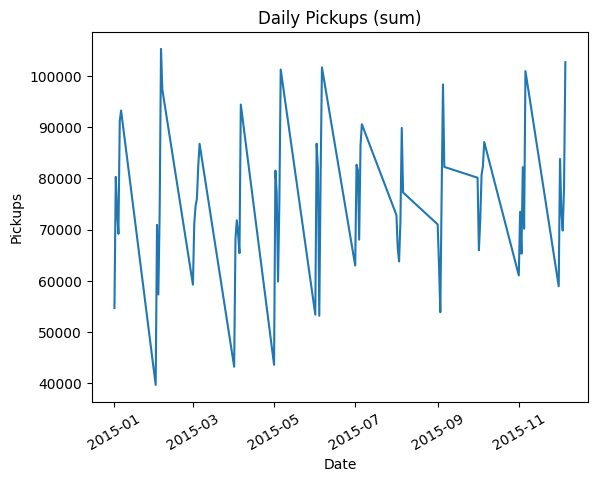

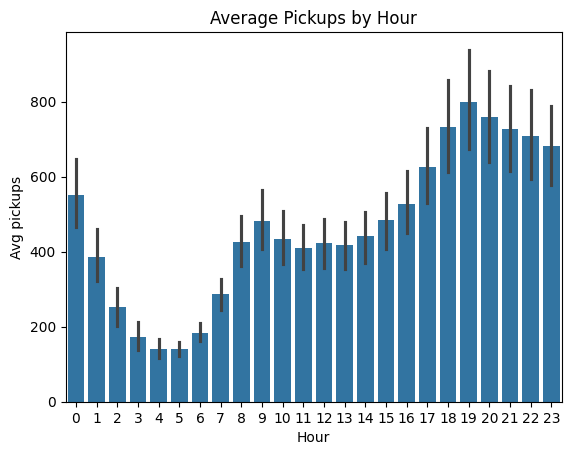

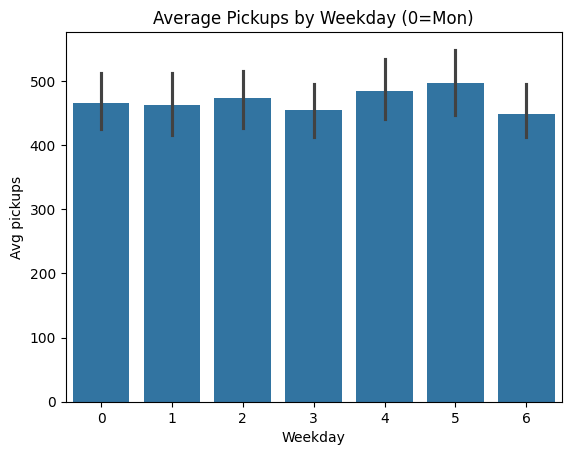

In [9]:
# Cell 6

import seaborn as sns, matplotlib.pyplot as plt

# Daily sums to smooth hourly noise
daily = (
    df.assign(date=df['pickup_dt'].dt.date)
      .groupby('date', as_index=False)['pickups'].sum()
)

plt.figure(); sns.lineplot(data=daily, x='date', y='pickups')
plt.title("Daily Pickups (sum)"); plt.xlabel("Date"); plt.ylabel("Pickups"); plt.xticks(rotation=30); plt.show()

# Hour-of-day (mean)
plt.figure(); sns.barplot(data=df, x='hour', y='pickups', estimator='mean')
plt.title("Average Pickups by Hour"); plt.xlabel("Hour"); plt.ylabel("Avg pickups"); plt.show()

# Weekday (mean)
plt.figure(); sns.barplot(data=df, x='weekday', y='pickups', estimator='mean')
plt.title("Average Pickups by Weekday (0=Mon)"); plt.xlabel("Weekday"); plt.ylabel("Avg pickups"); plt.show()


Section: Univariate Distributions
Objective: understand scale, skew, and tails for key numeric fields. Consider log view when heavy-tailed.

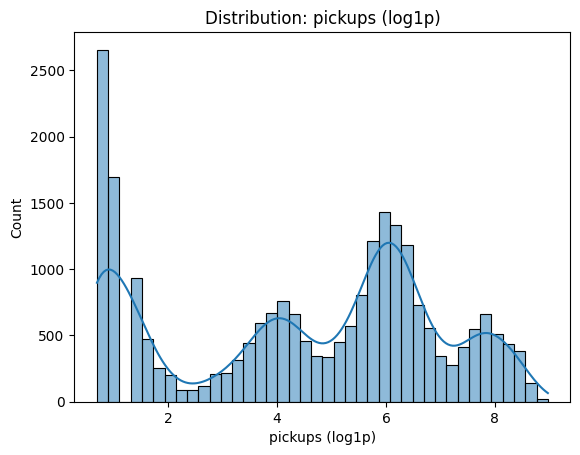

,0
count,23534.000000
mean,4.515243
std,2.445252
min,0.693147
p50,5.150393
p95,8.052217
max,8.972591


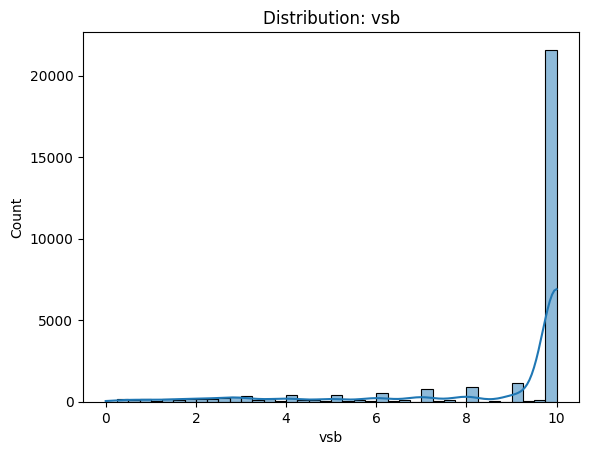

,0
count,29101.000000
mean,8.818125
std,2.442897
min,0.000000
p50,10.000000
p95,10.000000
max,10.000000


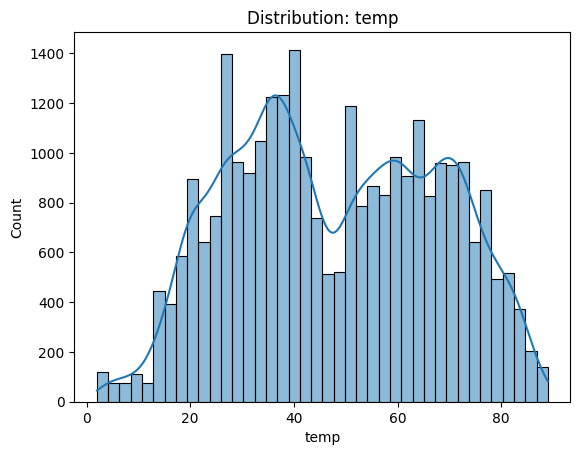

,0
count,28742.000000
mean,47.900019
std,19.798783
min,2.000000
p50,46.500000
p95,80.000000
max,89.000000


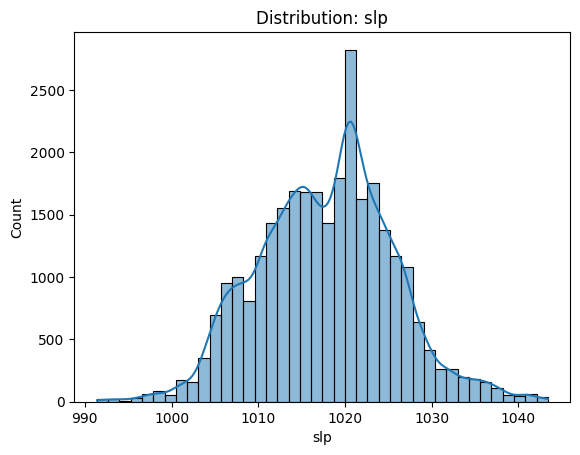

,0
count,29101.000000
mean,1017.817938
std,7.768796
min,991.400000
p50,1018.200000
p95,1030.000000
max,1043.400000


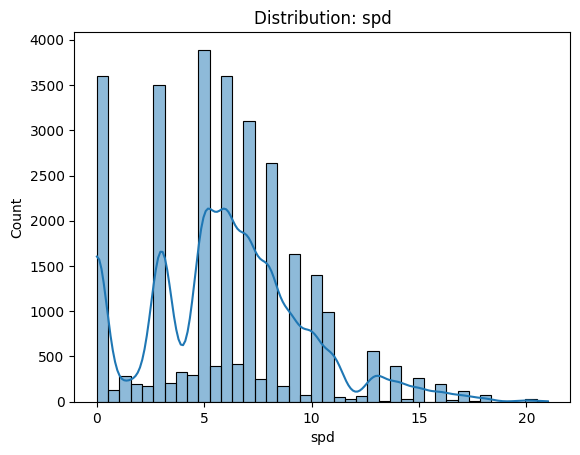

,0
count,29101.000000
mean,5.984924
std,3.699007
min,0.000000
p50,6.000000
p95,13.000000
max,21.000000


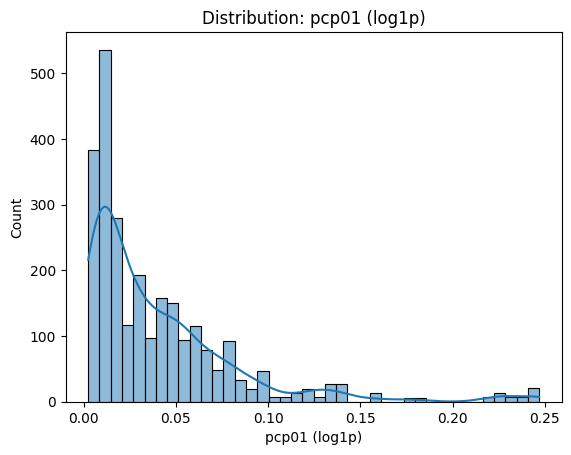

,0
count,2633.000000
mean,0.040462
std,0.043926
min,0.002497
p50,0.026317
p95,0.131028
max,0.246860


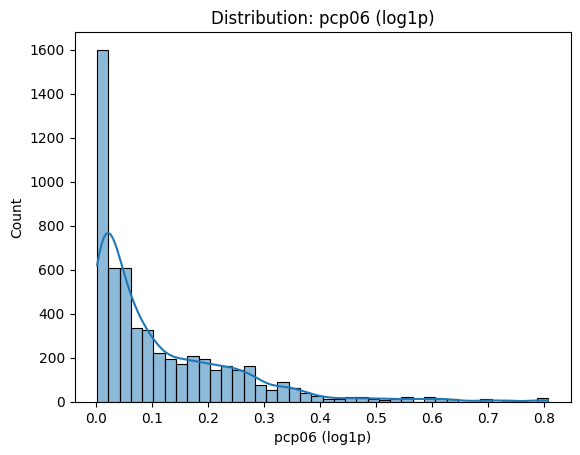

,0
count,5641.000000
mean,0.116818
std,0.132810
min,0.002497
p50,0.062975
p95,0.357674
max,0.806476


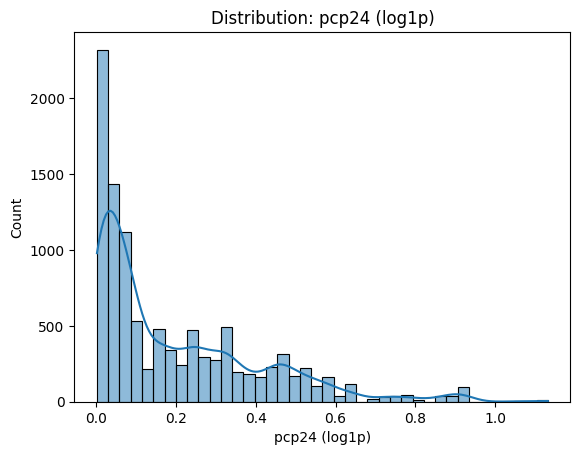

,0
count,10470.000000
mean,0.200174
std,0.209445
min,0.002497
p50,0.108854
p95,0.593327
max,1.131402


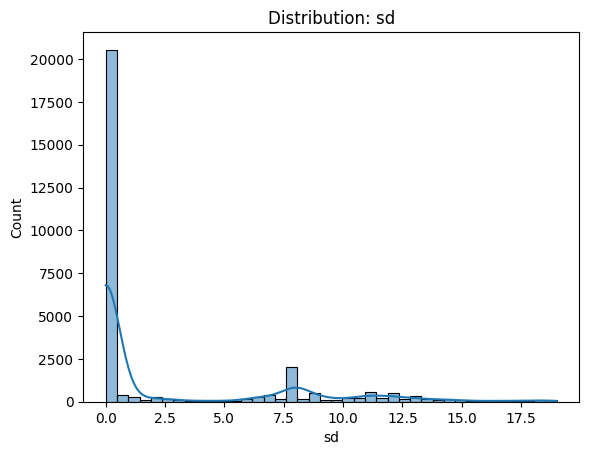

,0
count,29101.000000
mean,2.529169
std,4.520325
min,0.000000
p50,0.000000
p95,12.166667
max,19.000000


In [10]:
# Cell 7

num_cols = [c for c in ["pickups","vsb","temp","dewpt","slp","spd","pcp01","pcp06","pcp24","sd"] if c in df.columns]

def distplot(col, log=False):
    import seaborn as sns, matplotlib.pyplot as plt, numpy as np, pandas as pd
    s = df[col].dropna()
    if log:
        s = s[s>0]
        s = np.log1p(s)
        ttl = f"{col} (log1p)"
    else:
        ttl = col
    fig = plt.figure()
    sns.histplot(s, kde=True, bins=40)
    plt.title(f"Distribution: {ttl}")
    plt.xlabel(ttl); plt.ylabel("Count")
    plt.show()
    display(pd.Series({"count": s.shape[0], "mean": s.mean(), "std": s.std(), "min": s.min(), "p50": s.median(), "p95": s.quantile(.95), "max": s.max()}))

for c in num_cols:
    distplot(c, log=(c in ["pickups","pcp01","pcp06","pcp24"]))  # log for heavy-tailed counts/precip


Section: Correlation (Pearson) — Handle Time-Series Cautions
Objective: screen linear relationships, but avoid over-interpreting seasonality-driven correlations.

,pickups,vsb,temp,slp,spd,pcp01,pcp06,pcp24,sd
pickups,1.000,-0.007,0.054,-0.015,0.011,0.004,-0.003,-0.020,-0.008
vsb,-0.007,1.000,0.027,0.165,0.089,-0.487,-0.118,0.000,-0.048
temp,0.054,0.027,1.000,-0.216,-0.294,-0.014,-0.040,-0.016,-0.559
slp,-0.015,0.165,-0.216,1.000,-0.092,-0.088,-0.103,-0.134,0.124
spd,0.011,0.089,-0.294,-0.092,1.000,-0.000,0.016,-0.011,0.098
pcp01,0.004,-0.487,-0.014,-0.088,-0.000,1.000,0.126,0.001,-0.001
pcp06,-0.003,-0.118,-0.040,-0.103,0.016,0.126,1.000,0.254,0.040
pcp24,-0.020,0.000,-0.016,-0.134,-0.011,0.001,0.254,1.000,0.071
sd,-0.008,-0.048,-0.559,0.124,0.098,-0.001,0.040,0.071,1.000


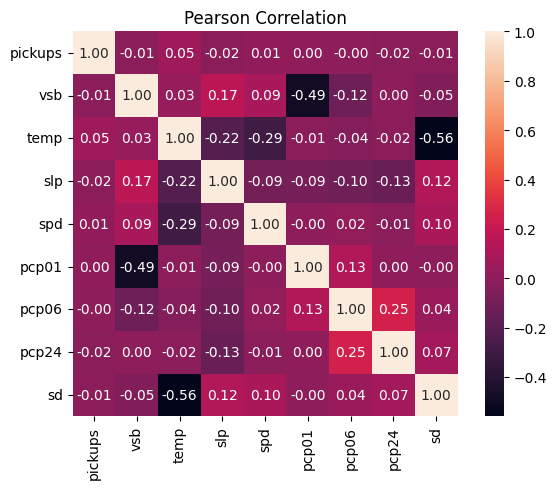

In [11]:
# Cell 8

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

corr_cols = [c for c in ["pickups","vsb","temp","dewpt","slp","spd","pcp01","pcp06","pcp24","sd"] if c in df.columns]
cmat = df[corr_cols].corr(method="pearson")
display(cmat.round(3))

plt.figure(figsize=(7,5))
sns.heatmap(cmat, annot=True, fmt=".2f", square=True)
plt.title("Pearson Correlation")
plt.show()


Section: Bivariate — Temporal Buckets
Objective: quantify patterns by month/day/hour/weekday.

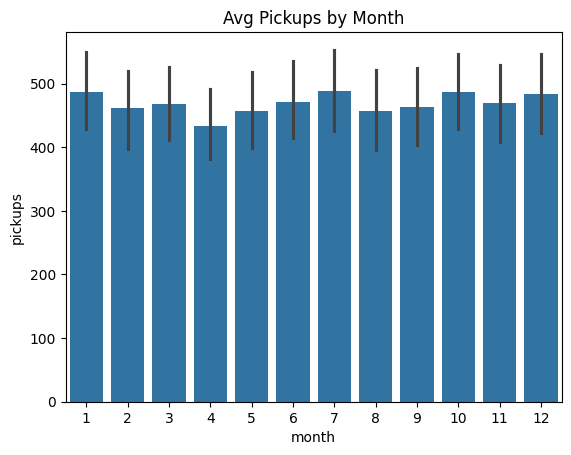

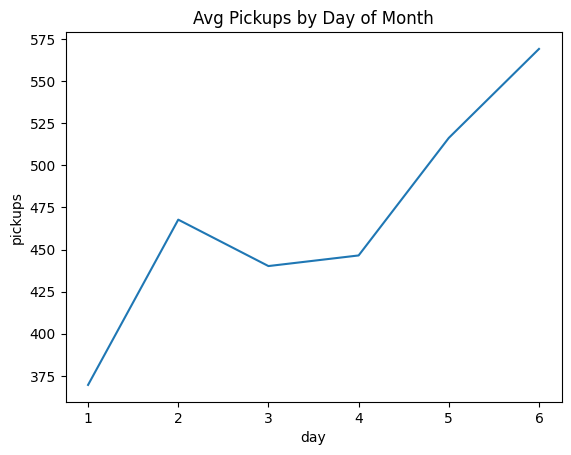

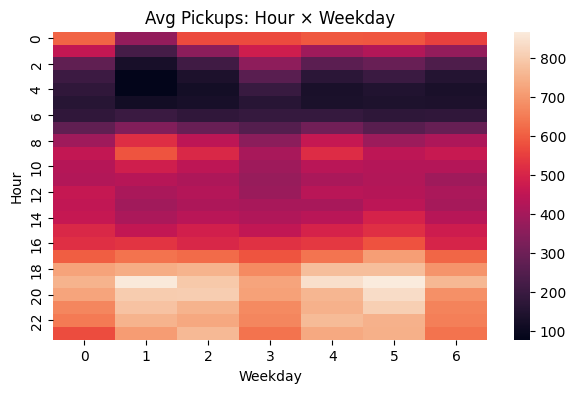

In [12]:
# Cell 9

import seaborn as sns, matplotlib.pyplot as plt

# Month (mean pickups)
plt.figure(); sns.barplot(data=df, x='month', y='pickups', estimator='mean')
plt.title("Avg Pickups by Month"); plt.show()

# Day of month (mean)
plt.figure(); sns.lineplot(data=df.groupby('day')['pickups'].mean().reset_index(), x='day', y='pickups')
plt.title("Avg Pickups by Day of Month"); plt.show()

# Hour × Weekday heatmap (mean)
hour_wd = df.pivot_table(index='hour', columns='weekday', values='pickups', aggfunc='mean')
plt.figure(figsize=(7,4)); sns.heatmap(hour_wd, annot=False); plt.title("Avg Pickups: Hour × Weekday"); plt.ylabel("Hour"); plt.xlabel("Weekday"); plt.show()


Section: Spatial — Borough Effects
Objective: compare magnitude and temporal profile by borough; avoid misleading means when sample sizes differ.

,rows
borough,
Bronx,4343
Brooklyn,4343
EWR,4343
Manhattan,4343
Queens,4343
Staten Island,4343


/tmp/ipython-input-567786436.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.lineplot(data=df.groupby(['borough','hour'])['pickups'].mean().reset_index(), x='hour', y='pickups', hue='borough')


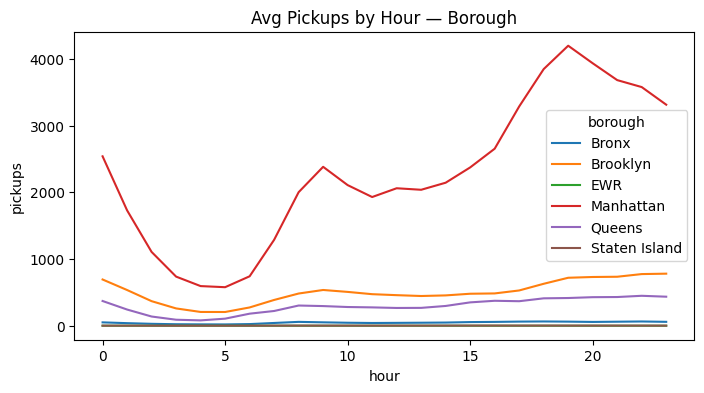

/tmp/ipython-input-567786436.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.lineplot(data=df.groupby(['borough','weekday'])['pickups'].mean().reset_index(), x='weekday', y='pickups', hue='borough')


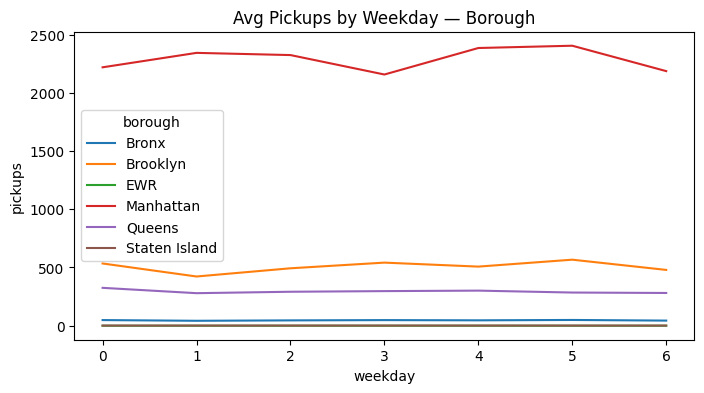

In [13]:
# Cell 10

import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# Support table
display(df['borough'].value_counts().to_frame('rows'))

# Hour-of-day by borough (mean)
plt.figure(figsize=(8,4))
sns.lineplot(data=df.groupby(['borough','hour'])['pickups'].mean().reset_index(), x='hour', y='pickups', hue='borough')
plt.title("Avg Pickups by Hour — Borough"); plt.show()

# Weekday by borough (mean)
plt.figure(figsize=(8,4))
sns.lineplot(data=df.groupby(['borough','weekday'])['pickups'].mean().reset_index(), x='weekday', y='pickups', hue='borough')
plt.title("Avg Pickups by Weekday — Borough"); plt.show()


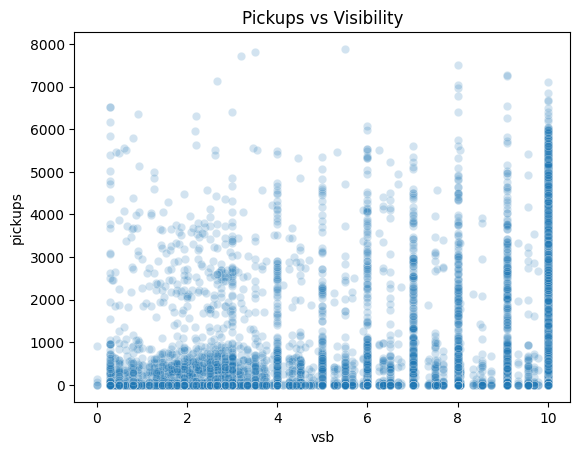

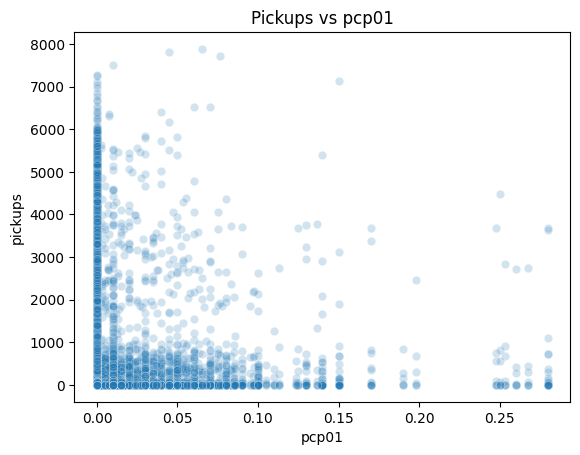

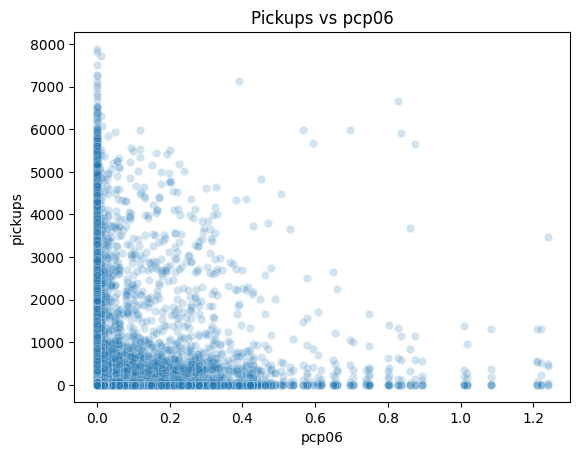

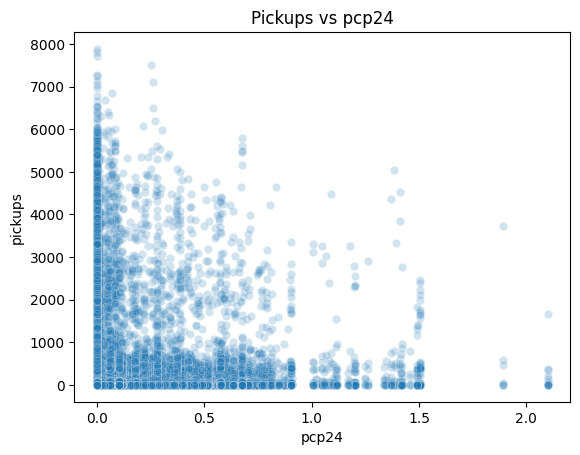

In [14]:
# Cell 11

import seaborn as sns, matplotlib.pyplot as plt

# Scatter with LOWESS (if seaborn>=0.13 uses lineplot with estimator)
plt.figure(); sns.scatterplot(data=df, x='vsb', y='pickups', alpha=0.2); plt.title("Pickups vs Visibility"); plt.show()

for p in [c for c in ["pcp01","pcp06","pcp24"] if c in df.columns]:
    plt.figure(); sns.scatterplot(data=df, x=p, y='pickups', alpha=0.2)
    plt.title(f"Pickups vs {p}"); plt.show()

if {'temp','dewpt'}.issubset(df.columns):
    plt.figure(); sns.scatterplot(data=df, x='temp', y='pickups', alpha=0.2); plt.title("Pickups vs Temp"); plt.show()
    plt.figure(); sns.scatterplot(data=df, x='dewpt', y='pickups', alpha=0.2); plt.title("Pickups vs Dew Point"); plt.show()


Section: Holidays / Special Causes
Objective: contrast typical vs holiday behavior.

/tmp/ipython-input-3075849095.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['date','is_holiday'], as_index=False)['pickups'].sum()


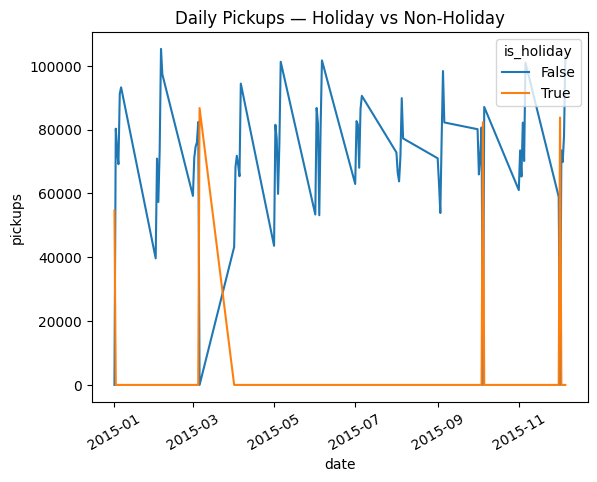

In [15]:
 # Cell 12

import seaborn as sns, matplotlib.pyplot as plt, pandas as pd

if 'is_holiday' in df.columns:
    daily_h = (
        df.assign(date=df['pickup_dt'].dt.date)
          .groupby(['date','is_holiday'], as_index=False)['pickups'].sum()
    )
    plt.figure(); sns.lineplot(data=daily_h, x='date', y='pickups', hue='is_holiday')
    plt.title("Daily Pickups — Holiday vs Non-Holiday"); plt.xticks(rotation=30); plt.show()
else:
    print("No holiday indicator found; skipping.")


Section: Outliers & Anomalies
Objective: detect extremes; decide whether to cap, winsorize, or isolate.

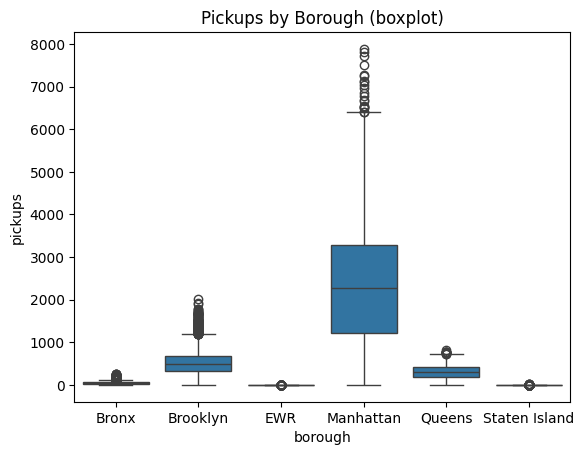

Outlier candidates: 3,498


,pickup_dt,borough,pickups
1,2015-01-01 01:00:00,Brooklyn,1519
3,2015-01-01 01:00:00,Manhattan,5258
10,2015-01-01 02:00:00,Brooklyn,1229
13,2015-01-01 02:00:00,Manhattan,4345
16,2015-01-01 03:00:00,Manhattan,4577


In [16]:
# Cell 13

import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

# Box/whisker by borough if present
if 'borough' in df.columns:
    plt.figure(); sns.boxplot(data=df, x='borough', y='pickups'); plt.title("Pickups by Borough (boxplot)"); plt.show()

# IQR rule on pickups
q1, q3 = df['pickups'].quantile([.25,.75])
iqr = q3 - q1
upper = q3 + 1.5*iqr
lower = max(0, q1 - 1.5*iqr)
anoms = df[(df['pickups'] > upper) | (df['pickups'] < lower)]
print(f"Outlier candidates: {len(anoms):,}")
display(anoms[['pickup_dt','borough','pickups']].head())


Section: Pulling Insights to Actions:

Peak windows by hour and weekday; borough-specific differences.

Weather sensitivity thresholds (visibility X, precipitation Y) where supply should pre-position.

Holiday uplift/deficit patterns → adjust baselines.

Outlier incidents → incident logs; treat separately from training data.

Extension 1 — Multivariate facet grids (hour × weekday × borough)
Purpose
This visualization answers the question: “How does demand behave when we slice by more than one temporal dimension and a spatial dimension at the same time?”
In a real operations setting (e.g., ride-hailing, logistics, dispatch), this is how you uncover granular scheduling and positioning patterns.

Why it matters in production

Staffing optimization: Different boroughs may have unique peak patterns; staff allocation can be tailored accordingly.

Cross-coverage planning: Identify boroughs with complementary peaks (so idle resources can be shifted).

Marketing/Promotions: Deploy offers in underutilized time/location segments.

Class discussion points

“If you had only 20 drivers for Manhattan between 10am and 4pm, which hours would you cut without hurting service?”

“Do weekend borough profiles resemble any weekday patterns?”

“What do you see in outer boroughs that might relate to inbound/outbound commuter flows?”

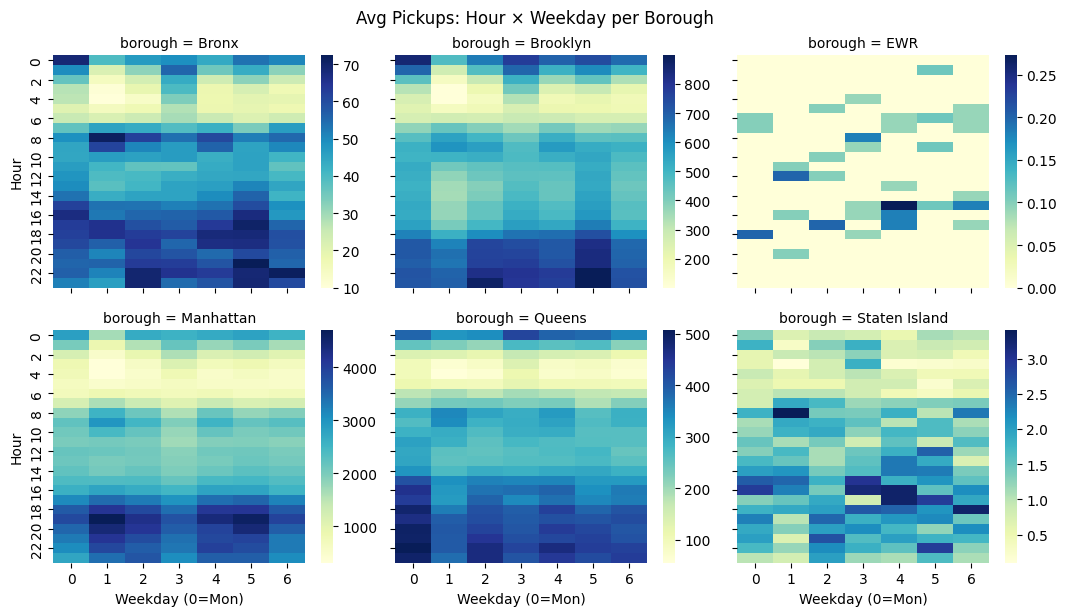

In [18]:
# demo extension 1

import seaborn as sns, matplotlib.pyplot as plt, numpy as np, pandas as pd

weekday_order = [0,1,2,3,4,5,6]
hour_index    = list(range(24))  # ensure full 0–23 grid

def facet_hour_weekday_heatmap(data, **kws):
    # data is the facet subset (one borough)
    mat = (
        data.groupby(["hour","weekday"])["pickups"]
            .mean()
            .unstack("weekday")
            .reindex(index=hour_index, columns=weekday_order)
            .astype(float)                              # ensure numeric
    )
    # If everything is NA, avoid seaborn error
    if mat.notna().to_numpy().sum() == 0:
        mat = pd.DataFrame(0.0, index=hour_index, columns=weekday_order)

    ax = sns.heatmap(mat, **kws)
    ax.set_ylabel("Hour")
    ax.set_xlabel("Weekday (0=Mon)")
    return ax

g = sns.FacetGrid(
    df,
    col="borough", col_wrap=3,
    height=3, aspect=1.2,
    margin_titles=True
)

g.map_dataframe(
    facet_hour_weekday_heatmap,
    cmap="YlGnBu", cbar=True
)

plt.suptitle("Avg Pickups: Hour × Weekday per Borough", y=1.02)
plt.show()



Extension 2 — Stratified correlation by hour-of-day
Purpose
Instead of a single correlation value for each variable, this stratifies correlations by hour-of-day.
We’re looking for relationships that vary depending on the time context — a common case in time-series and event-driven data.

Why it matters in production

Feature engineering: Hour-aware feature importance can improve predictive models (interaction terms, time-specific transformations).

Dynamic decision-making: If visibility impacts pickups more at night, operational strategies (alerts, driver routing) can be hour-specific.

Causal inference support: Helps rule in/out certain drivers for different temporal contexts.

Class discussion points

“Why might visibility be more correlated with demand pre-dawn than mid-day?”

“How could you operationalize an hour-aware model in real time?”

“If a variable flips correlation sign across hours, how should you treat it in modeling?”

/tmp/ipython-input-3469528971.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(corr_vs_pickups)


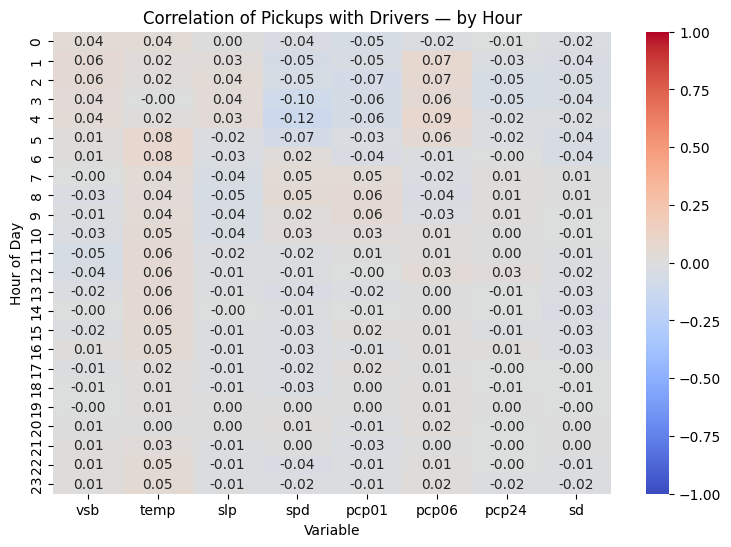

pickups,vsb,temp,slp,spd,pcp01,pcp06,pcp24,sd
hour,,,,,,,,
0,0.042175,0.043460,0.004200,-0.035563,-0.047357,-0.022150,-0.006452,-0.023682
1,0.056574,0.024218,0.028102,-0.054734,-0.045429,0.071527,-0.028178,-0.036640
2,0.062064,0.020941,0.039142,-0.048140,-0.066441,0.067890,-0.049952,-0.046541
3,0.038599,-0.000143,0.035682,-0.095336,-0.060252,0.061666,-0.051089,-0.039711
4,0.041515,0.015478,0.032142,-0.122393,-0.060365,0.085215,-0.020642,-0.022978
5,0.010825,0.079830,-0.019064,-0.069818,-0.029811,0.059232,-0.017003,-0.039661
6,0.013659,0.079432,-0.029528,0.016553,-0.038796,-0.012813,-0.000877,-0.039491
7,-0.003251,0.043971,-0.039069,0.046150,0.046701,-0.024497,0.012027,0.005038
8,-0.025923,0.036378,-0.047418,0.048742,0.056216,-0.038969,0.011072,0.007319


In [20]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

# Choose from what's actually available
base = ["pickups","vsb","temp","dewpt","slp","spd","pcp01","pcp06","pcp24","sd"]
avail = [c for c in base if c in df.columns]

if "pickups" not in avail:
    raise ValueError("Column 'pickups' not found; cannot compute correlations.")

# Keep only needed columns and enforce numeric
sub = df[["hour"] + avail].copy()
sub = sub.dropna(subset=["hour"])
sub["hour"] = sub["hour"].astype(int)

for c in avail:
    sub[c] = pd.to_numeric(sub[c], errors="coerce")

# Helper: return the correlation row vs 'pickups' for a group's numeric columns
def corr_vs_pickups(g: pd.DataFrame) -> pd.Series:
    mat = g[avail].corr(method="pearson")
    if "pickups" not in mat.index:
        return pd.Series(dtype=float)
    row = mat.loc["pickups"].drop(labels=["pickups"], errors="ignore")
    # Ensure consistent column order across hours
    return row.reindex([c for c in avail if c != "pickups"])

# Compute per-hour correlations
corr_by_hour = (
    sub.groupby("hour", as_index=True)
       .apply(corr_vs_pickups)
       .reindex(range(24))  # full 0..23 grid
)

# If all-NaN (e.g., very sparse data), avoid plotting crash
if corr_by_hour.notna().to_numpy().sum() == 0:
    print("No sufficient data to compute stratified correlations.")
else:
    plt.figure(figsize=(9, 6))
    sns.heatmap(
        corr_by_hour,
        annot=True, fmt=".2f",
        cmap="coolwarm", center=0, vmin=-1, vmax=1
    )
    plt.title("Correlation of Pickups with Drivers — by Hour")
    plt.ylabel("Hour of Day")
    plt.xlabel("Variable")
    plt.show()

display(corr_by_hour)



Extension 3 — Rolling-window trends & anomaly detection
Purpose
A lightweight statistical approach for detecting anomalies in aggregated demand.
It uses a rolling mean and standard deviation to flag extreme deviations, which are then marked as anomalies.

Why it matters in production

Monitoring & alerts: In dispatch/logistics, even a simple z-score can flag outages, special events, or system problems.

Baseline setting: Can feed into automated scaling (e.g., dynamic resource allocation).

Event post-mortem: Once flagged, anomalies can be tagged with contextual metadata for later root cause analysis.

Class discussion points

“What’s the trade-off between sensitivity and false alarms when choosing the z-score threshold?”

“Would you use a fixed rolling window in production, or adapt it?”

“How could you combine this with machine learning anomaly detection?”


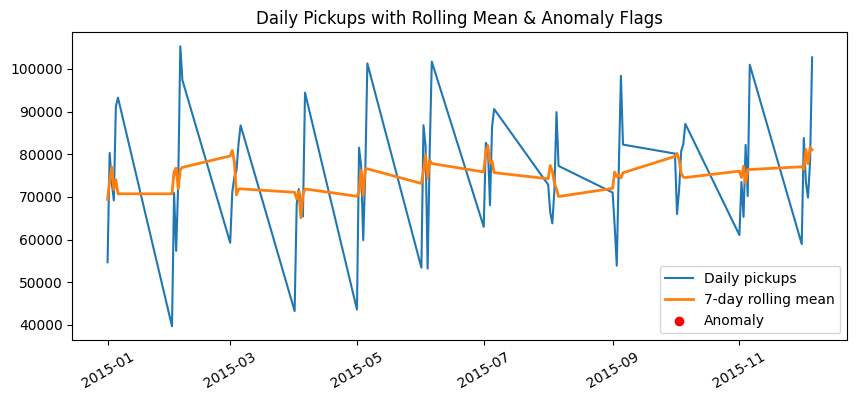

,date,pickups,rolling_mean,rolling_std,z_score,is_anomaly


In [21]:
import pandas as pd, numpy as np

# Daily aggregate
daily = (
    df.assign(date=df['pickup_dt'].dt.date)
      .groupby('date', as_index=False)['pickups'].sum()
)

# Rolling mean & std for anomaly detection
window = 7
daily['rolling_mean'] = daily['pickups'].rolling(window, min_periods=1, center=True).mean()
daily['rolling_std'] = daily['pickups'].rolling(window, min_periods=1, center=True).std()

# Z-score for anomaly threshold
daily['z_score'] = (daily['pickups'] - daily['rolling_mean']) / daily['rolling_std']
threshold = 3
daily['is_anomaly'] = daily['z_score'].abs() > threshold

# Plot
plt.figure(figsize=(10,4))
plt.plot(daily['date'], daily['pickups'], label='Daily pickups')
plt.plot(daily['date'], daily['rolling_mean'], label=f'{window}-day rolling mean', linewidth=2)
plt.scatter(daily.loc[daily['is_anomaly'], 'date'],
            daily.loc[daily['is_anomaly'], 'pickups'],
            color='red', label='Anomaly', zorder=5)
plt.legend()
plt.title("Daily Pickups with Rolling Mean & Anomaly Flags")
plt.xticks(rotation=30)
plt.show()

display(daily.loc[daily['is_anomaly']])
